<a href="https://colab.research.google.com/github/Fatimalbasha/KAUST-Labs2026/blob/main/Stage2/Day_2/Day2_Exercise_MultiClassClassification_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image.png](https://i.imgur.com/a3uAqnb.png)



# **Multi-Class Classification**

---
In this lab, you'll learn how to train ML Models for **multi-class classification**

# 📊 **Data**
https://www.kaggle.com/datasets/devitachi/mashroom-dataset


> This is a **Multiclass-Classification** problem.


The data contains the following columns:
Columns in the DataFrame:
['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


> **Target**: class

# Main Task
Analyze the "devitachi/mashroom-dataset" from Kaggle, including data exploration, handling missing values and duplicates, and visualizing feature distributions. Implement Softmax, categorical cross-entropy, and One-Hot Encoding from scratch using NumPy. Then, define and train multiple machine learning models (e.g., Logistic Regression, Decision Tree, Random Forest, SVM) using K-Fold Cross-Validation, evaluate their performance using various metrics (accuracy, precision, recall, F1-score, confusion matrix), and provide a summary of findings and insights.

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("Libraries imported successfully.")

Libraries imported successfully.


## Download and Load Dataset




In [ ]:
import os

download_path = kagglehub.dataset_download('devitachi/mashroom-dataset')

# Construct the full path to the CSV file using os.path.join
# Correcting the filename to 'mushrooms.csv' based on common Kaggle dataset names
csv_file_path = os.path.join(download_path, 'mushrooms.csv')

df = pd.read_csv(csv_file_path)

print(f"Dataset downloaded to: {download_path}")
print(f"CSV file loaded from: {csv_file_path}")
print("First 5 rows of the DataFrame:")
df.head()

Dataset downloaded to: /root/.cache/kagglehub/datasets/devitachi/mashroom-dataset/versions/1
CSV file loaded from: /root/.cache/kagglehub/datasets/devitachi/mashroom-dataset/versions/1/mushrooms.csv
First 5 rows of the DataFrame:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## Initial Data Exploration and Missing Value Analysis



In [ ]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-co

In [ ]:
print("\nDataFrame Description:")
df.describe()


DataFrame Description:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [ ]:
print("\nMissing Values (df.isnull().sum()):")
print(df.isnull().sum())


Missing Values (df.isnull().sum()):
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


### Data Exploration Summary

From the initial data exploration, the following observations have been made:

*   **Data Types**: All 23 columns in the DataFrame are of `object` dtype, indicating that they are categorical features. This is expected for a dataset like the mushroom dataset, where features are typically descriptive attributes.
*   **Missing Values**: There are no explicit missing values (NaN) in any of the columns, as confirmed by `df.isnull().sum()`. Each column has 8124 non-null entries, matching the total number of rows.
*   **Overall Structure**: The DataFrame consists of 8124 entries and 23 columns. The target variable is likely the 'class' column, which also appears to be categorical.


**Reasoning**:
To address the subtask, I will first check for and remove any duplicate rows in the DataFrame. Then, I will analyze the distribution of the target variable, 'class', using value counts and visualize it with a seaborn count plot to identify any class imbalance.



In [ ]:
print("Checking for duplicate rows...")
duplicate_rows = df.duplicated().sum()
if duplicate_rows > 0:
    print(f"Found {duplicate_rows} duplicate rows. Removing them...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")



Checking for duplicate rows...
No duplicate rows found.


In [ ]:
print("\nValue counts for the target variable 'class':")
class_distribution = df['class'].value_counts()
print(class_distribution)


Value counts for the target variable 'class':
class
e    4208
p    3916
Name: count, dtype: int64


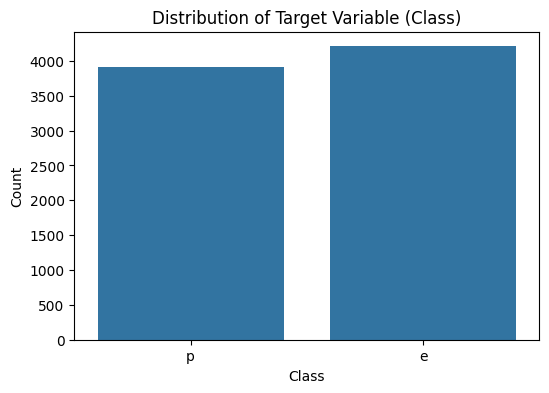

In [ ]:

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class')
plt.title('Distribution of Target Variable (Class)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

**Reasoning**:
To visualize the distribution of each categorical feature, I will iterate through all columns except 'class', and for each feature, create a seaborn count plot with appropriate labels and title, and handle x-axis label rotation for better readability.



Plotting feature distributions...


/tmp/ipython-input-2734597384.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='viridis')


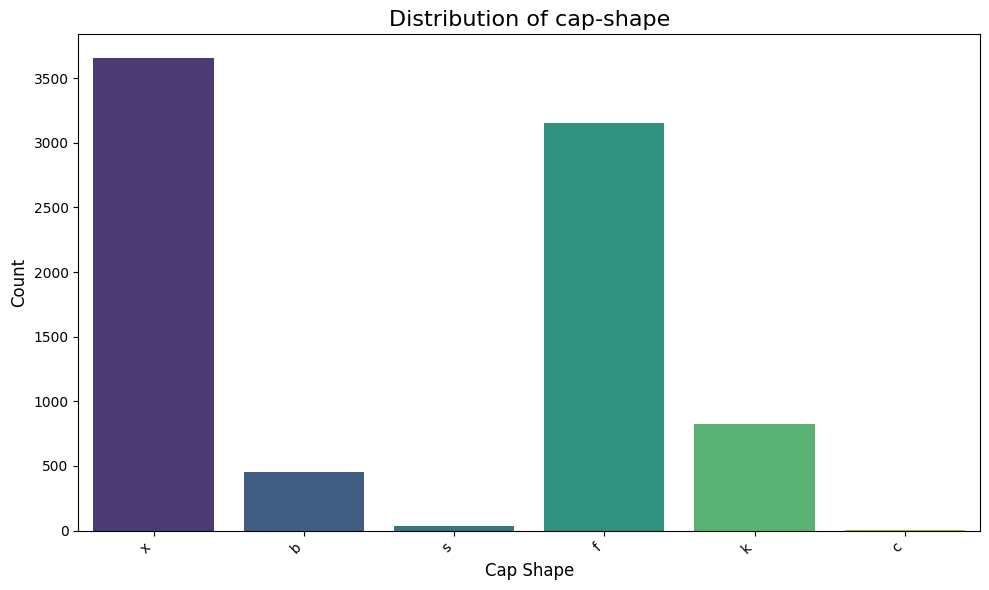

/tmp/ipython-input-2734597384.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='viridis')


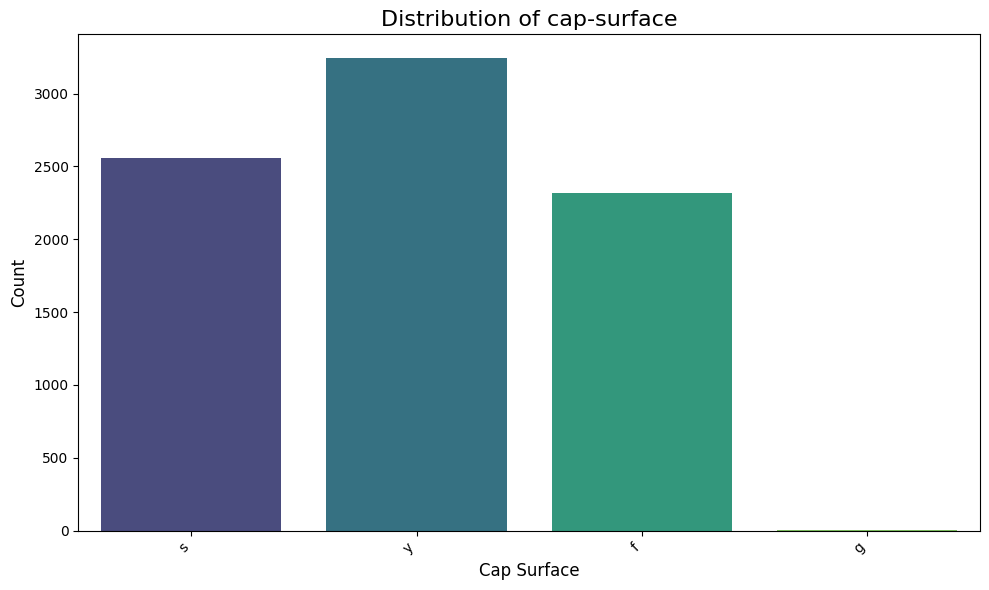

/tmp/ipython-input-2734597384.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette='viridis')


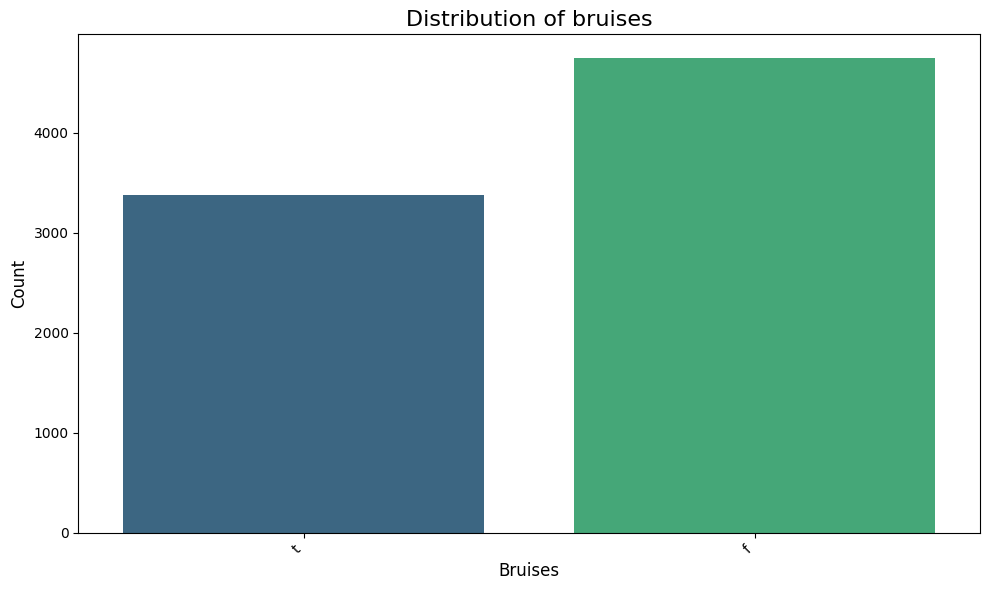

All feature distributions plotted successfully.


In [ ]:
print("Plotting feature distributions...")

# Identify feature columns (all columns except 'class')
feature_columns = ["cap-shape", "cap-surface", "bruises"]

# Iterate through each feature and create a count plot
for feature in feature_columns:
    plt.figure(figsize=(10, 6)) # Adjust figure size dynamically if needed
    sns.countplot(data=df, x=feature, palette='viridis')
    plt.title(f'Distribution of {feature}', fontsize=16)
    plt.xlabel(feature.replace('-', ' ').title(), fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

print("All feature distributions plotted successfully.")

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without explicitly assigning `hue`. To fix this and follow the recommended practice for `seaborn.countplot`, I will assign `hue=feature` and set `legend=False`.



## Encode Categorical Features and Target Variable

### task:
Identify all categorical columns (features and target). Apply One-Hot Encoding for features and Label Encoding for the target variable to prepare them for model training.


**Reasoning**:
To prepare the data for model training, I will first separate the target variable 'class' from the features. Then, I will apply Label Encoding to the target variable 'y' and One-Hot Encoding to the feature DataFrame 'X'. Finally, I will verify the shapes of the encoded dataframes.



In [ ]:
print("Separating target variable and features...")
X = df.drop('class', axis=1)
y = df['class']

print("Applying Label Encoding to target variable 'y'...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Applying One-Hot Encoding to feature DataFrame 'X'...")
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = pd.DataFrame(onehot_encoder.fit_transform(X), columns=onehot_encoder.get_feature_names_out(X.columns))

print("Verification of encoded data shapes:")
print(f"Shape of X_encoded: {X_encoded.shape}")
print(f"Shape of y_encoded: {y_encoded.shape}")

print("First 5 rows of X_encoded:")
display(X_encoded.head())
print("First 5 elements of y_encoded:")
print(y_encoded[:5])


Separating target variable and features...
Applying Label Encoding to target variable 'y'...
Applying One-Hot Encoding to feature DataFrame 'X'...
Verification of encoded data shapes:
Shape of X_encoded: (8124, 117)
Shape of y_encoded: (8124,)
First 5 rows of X_encoded:


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


First 5 elements of y_encoded:
[1 0 0 1 0]


## Data Preparation (Splitting and Scaling)

### task:
Separate the features (X) and the target (y) from the processed DataFrame. Split the data into training and testing sets (e.g., 70-30 or 80-20 ratio). Apply feature scaling (e.g., StandardScaler or MinMaxScaler) to numerical features if present and necessary for the chosen models.


**Reasoning**:
To prepare the data for model training, I will split the `X_encoded` features and `y_encoded` target variable into training and testing sets using `train_test_split` with a test size of 0.3 and a `random_state` for reproducibility.



In [ ]:
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

print("Data split successful.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Splitting data into training and testing sets...
Data split successful.
Shape of X_train: (5686, 117)
Shape of X_test: (2438, 117)
Shape of y_train: (5686,)
Shape of y_test: (2438,)


## Implement Multiclass Logistic Regression Components

### task:
As requested, implement the Softmax function, categorical cross-entropy loss function, and One-Hot Encoding from scratch using NumPy to deepen understanding of multi-class classification principles.


**Reasoning**:
I will define the `softmax`, `categorical_cross_entropy`, and `one_hot_encode` functions from scratch using NumPy as specified in the instructions, ensuring numerical stability for softmax and handling log(0) for cross-entropy, and then verify their functionality with simple examples.



In [ ]:
print("Defining custom NumPy implementations for Softmax, Categorical Cross-Entropy, and One-Hot Encoding...")

def softmax(z):
    """Compute softmax values for each set of scores in z."""
    # Subtract max for numerical stability
    e_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return e_z / np.sum(e_z, axis=-1, keepdims=True)

def categorical_cross_entropy(y_true, y_pred):
    """Compute categorical cross-entropy loss."""
    epsilon = 1e-10 # Small value to prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
    loss = -np.sum(y_true * np.log(y_pred), axis=-1)
    return np.mean(loss)

def one_hot_encode(labels, num_classes):
    """Convert integer labels to one-hot encoded format."""
    one_hot = np.zeros((len(labels), num_classes))
    one_hot[np.arange(len(labels)), labels] = 1
    return one_hot

print("Functions defined. Testing with example data...")

# Example usage:
# Test Softmax
z_test = np.array([[1.0, 2.0, 3.0], [0.5, 1.5, 2.5]])
softmax_output = softmax(z_test)
print(f"\nSoftmax Output:\n{softmax_output}")
print(f"Softmax Row Sums (should be ~1): {np.sum(softmax_output, axis=1)}")

# Test One-Hot Encode
labels_test = np.array([0, 2, 1, 0])
num_classes_test = 3
one_hot_output = one_hot_encode(labels_test, num_classes_test)
print(f"\nOne-Hot Encoding Output:\n{one_hot_output}")

# Test Categorical Cross-Entropy
y_true_test = one_hot_encode(np.array([0, 1, 2]), 3) # True labels
y_pred_test = np.array([[0.8, 0.1, 0.1], [0.1, 0.7, 0.2], [0.1, 0.2, 0.7]]) # Predicted probabilities
loss_output = categorical_cross_entropy(y_true_test, y_pred_test)
print(f"\nCategorical Cross-Entropy Loss: {loss_output}")

print("Custom functions implemented and tested.")

Defining custom NumPy implementations for Softmax, Categorical Cross-Entropy, and One-Hot Encoding...
Functions defined. Testing with example data...

Softmax Output:
[[0.09003057 0.24472847 0.66524096]
 [0.09003057 0.24472847 0.66524096]]
Softmax Row Sums (should be ~1): [1. 1.]

One-Hot Encoding Output:
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]

Categorical Cross-Entropy Loss: 0.3121644797305582
Custom functions implemented and tested.


## Define and Train Machine Learning Models with Cross-Validation

### task:
Define multiple machine learning models suitable for multi-class classification (e.g., Logistic Regression, Decision Tree, Random Forest, SVM) with chosen hyperparameters. Train these models using K-Fold Cross-Validation to get a robust estimate of performance and calculate average losses across folds.


**Reasoning**:
I will initialize the specified machine learning models and `KFold` object. Then, I will iterate through each model, perform K-Fold Cross-Validation, train the model, predict probabilities, one-hot encode the true labels, calculate the custom categorical cross-entropy loss for each fold, and store the average loss for each model in a dictionary. Finally, I will print the average loss for each model to track their performance.



In [ ]:
print("Initializing models and K-Fold cross-validation...")

# Determine the number of classes for one-hot encoding
num_classes = len(np.unique(y_encoded))

# 1. Initialize the machine learning models
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42) # probability=True is needed for .predict_proba
}

# 2. Create a KFold object
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Create an empty dictionary to store average losses
model_losses = {}

print("Starting K-Fold Cross-Validation for each model...")

# 4. For each model:
for model_name, model in models.items():
    print(f"\nTraining and evaluating {model_name}...")
    fold_losses = [] # List to store loss from each fold

    for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
        # Split X_train and y_train into training and validation sets for the current fold
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        # Train the current model
        model.fit(X_train_fold, y_train_fold)

        # Generate predictions (probabilities) on the validation set
        y_pred_proba = model.predict_proba(X_val_fold)

        # Convert y_val_fold (true labels) into a one-hot encoded format
        y_val_one_hot = one_hot_encode(y_val_fold, num_classes)

        # Calculate categorical cross-entropy loss for the current fold
        loss = categorical_cross_entropy(y_val_one_hot, y_pred_proba)
        fold_losses.append(loss)

    # Calculate the average loss for the model
    avg_loss = np.mean(fold_losses)
    model_losses[model_name] = avg_loss

    # Print the average cross-validation loss for the current model
    print(f"{model_name} - Average Cross-Validation Loss: {avg_loss:.4f}")

print("\nAll models trained and evaluated. Stored average losses:")
print(model_losses)

Initializing models and K-Fold cross-validation...
Starting K-Fold Cross-Validation for each model...

Training and evaluating Logistic Regression...
Logistic Regression - Average Cross-Validation Loss: 0.0077

Training and evaluating Decision Tree...
Decision Tree - Average Cross-Validation Loss: 0.0041

Training and evaluating Random Forest...
Random Forest - Average Cross-Validation Loss: 0.0006

Training and evaluating SVM...
SVM - Average Cross-Validation Loss: 0.0004

All models trained and evaluated. Stored average losses:
{'Logistic Regression': np.float64(0.0076799529899665596), 'Decision Tree': np.float64(0.004050281705952598), 'Random Forest': np.float64(0.0006242954193316075), 'SVM': np.float64(0.00038419025882511473)}


## Evaluate Model Performance

### task:
Evaluate the performance of the trained models on the test set. Calculate and display relevant metrics such as accuracy, precision, recall, F1-score, and generate a confusion matrix for each model. Visualize the confusion matrices or other performance comparison plots.


**Reasoning**:
To evaluate the performance of each trained model, I will iterate through the models, make predictions on the test set, calculate accuracy, precision, recall, and F1-score, and visualize the confusion matrix for each model using a heatmap.



Evaluating models on the test set...

Evaluating Logistic Regression...
  Accuracy: 0.9996
  Precision: 0.9996
  Recall: 0.9996
  F1-Score: 0.9996


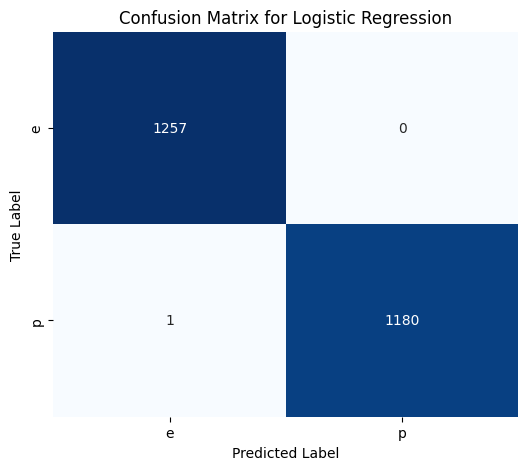


Evaluating Decision Tree...
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000


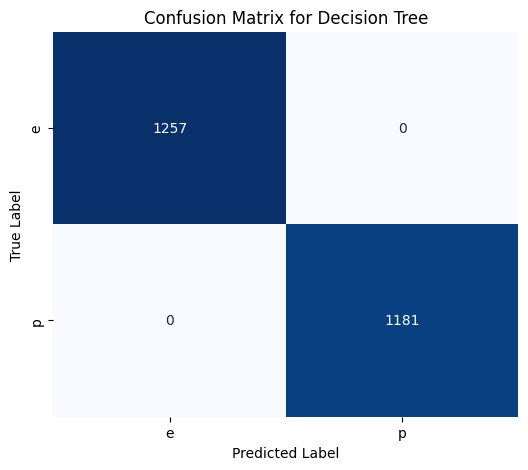


Evaluating Random Forest...
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000


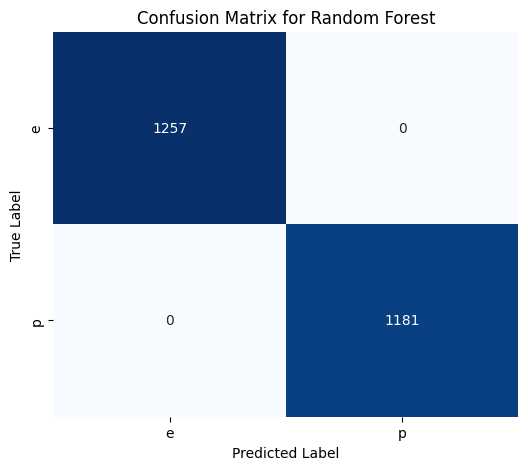


Evaluating SVM...
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000


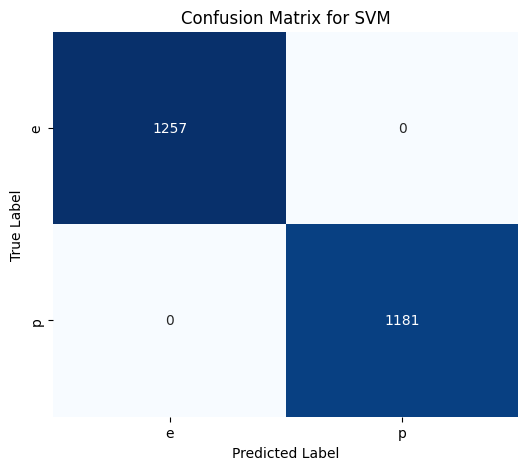


All models evaluated.


In [ ]:
print("Evaluating models on the test set...")

# Dictionary to store performance metrics
model_performance = {}

# Iterate through each trained model
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")

    # Make predictions on the test set (hard labels)
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store metrics
    model_performance[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    # Print metrics
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

    # Generate and visualize Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

print("\nAll models evaluated.")

# **Contribution By: Mohammed Bremoo**